#Recommendation System


Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\anime.csv")
df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


Data Description:

Unique ID of each anime.
Anime title.
Anime broadcast type, such as TV, OVA, etc.
anime genre.
The number of episodes of each anime.
The average rating for each anime compared to the number of users who gave ratings.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


Handle missing values, if any.

In [67]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

<Axes: >

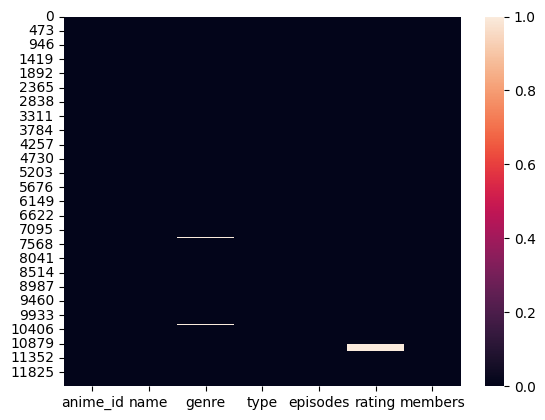

In [68]:
sns.heatmap(df.isna())

In [69]:
for i in df.isna().sum():
    print((i/len(df))*100)

0.0
0.0
0.504311046038718
0.20335122824141857
0.0
1.8708312998210508
0.0


In [70]:
numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns
for col in numeric_cols:
    if df[col].isnull().sum()>0: 
        if abs(df[col].skew())>1:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())

In [71]:
df['genre'] = df['genre'].fillna('')
df['type'] = df['type'].fillna(df['type'].mode()[0])

In [72]:
df.isnull().sum() 

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

Explore the dataset to understand its structure and attributes.

In [73]:
df.shape

(12294, 7)

In [74]:
df.describe()

,anime_id,rating,members
count,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.017096,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.900000,2.250000e+02
50%,10260.500000,6.550000,1.550000e+03
75%,24794.500000,7.170000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [76]:
len(df.anime_id.unique())

12294

In [77]:
df['rating'].value_counts()

rating
6.473902    230
6.000000    141
7.000000     99
6.500000     90
6.250000     84
           ... 
2.550000      1
9.370000      1
2.970000      1
2.860000      1
3.140000      1
Name: count, Length: 599, dtype: int64

<Axes: >

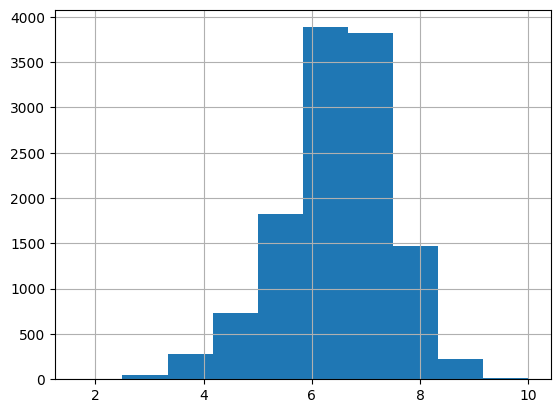

In [78]:
df['rating'].hist()

In [79]:
df.name.value_counts()

name
Saru Kani Gassen                                             2
Shi Wan Ge Leng Xiaohua                                      2
Pink no Curtain                                              1
Original Video Romance Animation                             1
Gintama°                                                     1
                                                            ..
Nudl Nude 2                                                  1
Nuki Doki! Tenshi to Akuma no Sakusei Battle - Revolution    1
Onna Spy Goumon: Teki no Ajito wa Jotai Goumonsho            1
Original C-V-P Momoko                                        1
Steins;Gate                                                  1
Name: count, Length: 12292, dtype: int64

Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).

In [80]:
features = df[['genre', 'rating', 'type', 'episodes']]

(features.head())

,genre,rating,type,episodes
0,"Drama, Romance, School, Supernatural",9.37,Movie,1
1,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,TV,64
2,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,TV,51
3,"Sci-Fi, Thriller",9.17,TV,24
4,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,TV,51


Convert categorical features into numerical representations if necessary.
Normalize numerical features if required.

In [82]:
if 'type' in df.columns:  
    df = pd.get_dummies(df, columns=['type'], prefix='type', dummy_na=False)
else:
    for t in ['type_Movie','type_Music','type_ONA','type_OVA','type_Special','type_TV']:
        if t not in df.columns:
            df[t] = 0
df

,anime_id,name,genre,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",1,9.37,200630,True,False,False,False,False,False
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",64,9.26,793665,False,False,False,False,False,True
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",51,9.25,114262,False,False,False,False,False,True
3,9253,Steins;Gate,"Sci-Fi, Thriller",24,9.17,673572,False,False,False,False,False,True
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",51,9.16,151266,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,1,4.15,211,False,False,False,True,False,False
12290,5543,Under World,Hentai,1,4.28,183,False,False,False,True,False,False
12291,5621,Violence Gekiga David no Hoshi,Hentai,4,4.88,219,False,False,False,True,False,False
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,1,4.98,175,False,False,False,True,False,False


In [84]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['rating']   = pd.to_numeric(df['rating'], errors='coerce')
df['members']  = pd.to_numeric(df['members'], errors='coerce')

df['episodes'].fillna(df['episodes'].median(), inplace=True)
df['rating'].fillna(df['rating'].median(), inplace=True)
df['members'].fillna(df['members'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14940\3203435057.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['episodes'].fillna(df['episodes'].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14940\3203435057.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words = 'english')
genre_matrix = tfidf.fit_transform(df['genre']) 

In [87]:
scaler = MinMaxScaler()
num_cols = ['episodes','rating','members']
num_matrix = scaler.fit_transform(df[num_cols])   

In [88]:
type_cols = [c for c in df.columns if c.startswith('type_')]
type_matrix = df[type_cols].values 

In [90]:
import scipy.sparse as sp
full_matrix = sp.hstack([genre_matrix, num_matrix,type_matrix])

In [91]:
#Recommendation System:
from sklearn.metrics.pairwise import cosine_similarity

In [96]:
similarity_matrix  = cosine_similarity(full_matrix) 
def find_index_by_name(title):
    matches = df.index[df['name'].str.lower() == title.lower()].tolist()
    if len(matches) == 0:
        raise valueError("Anime not found")
    return matches[0]

def get_similarity_vactor(idx): 
    return similarity_matrix[idx]

Design a function to recommend anime based on cosine similarity.

In [104]:
def recommend_anime(title, top_n=5, threshold=0.0, filter_type=None): 
    try: 
        idx = find_index_by_name(title)
    except ValueError:
        return f"'{title}' not found in dataset."

    sims = get_similarity_vactor(idx)

    res = pd.DataFrame({
        'index': np.arange(len(sims)),
        'name': df['name'],
        'score': sims
    })

    res = res[res['index'] != idx]
    res = res[res['score'] >= threshold]

    if filter_type and filter_type in df.columns:
        res = res[df[filter_type].values[res['index']]]

    res = res.sort_values("score", ascending=False).head(top_n)

    out = df.loc[res['index'], ['anime_id', 'name', 'genre', 'episodes', 'rating']].copy()
    out['score'] = res['score'].values
    out.reset_index(drop=True, inplace=True)

    return out


Given a target anime, recommend a list of similar anime based on cosine similarity scores.

In [107]:
recommend_anime("Naruto", top_n=5) 


,anime_id,name,genre,episodes,rating,score
0,1735,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",2.0,7.94,0.994188
1,813,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",291.0,8.32,0.962160
2,223,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",153.0,8.16,0.944643
3,6033,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",97.0,7.95,0.923485
4,30694,Dragon Ball Super,"Action, Adventure, Comedy, Fantasy, Martial Ar...",2.0,7.40,0.920332


Experiment with different threshold values for similarity scores to adjust the recommendation list size.

In [110]:
def threshold_experiment(title, thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]):
    results = []

    try:
        idx = find_index_by_name(title)
    except ValueError:
        print(f"'{title}' not found.")
        return
    
    sims = get_similarity_vactor(idx)

    print(f"\n Threshold Experiment for: {title}\n")
    for t in thresholds:
        count = (sims >= t).sum() - 1       # -1 to exclude itself
        results.append((t, count))
        print(f"Threshold {t:.2f} → {count} similar anime")

    return results



In [111]:
threshold_results = threshold_experiment("Naruto")



 Threshold Experiment for: Naruto

Threshold 0.00 → 12293 similar anime
Threshold 0.10 → 11965 similar anime
Threshold 0.20 → 6593 similar anime
Threshold 0.30 → 4271 similar anime
Threshold 0.40 → 3984 similar anime
Threshold 0.50 → 3812 similar anime


In [112]:
for t in [0.0, 0.2, 0.3, 0.4]:
    print(f"Recommendations at Threshold {t}")
    print(recommend_anime("Naruto", top_n=5, threshold=t))

Recommendations at Threshold 0.0
   anime_id                name  \
0      1735  Naruto: Shippuuden   
1       813       Dragon Ball Z   
2       223         Dragon Ball   
3      6033     Dragon Ball Kai   
4     30694   Dragon Ball Super   

                                               genre  episodes  rating  \
0  Action, Comedy, Martial Arts, Shounen, Super P...       2.0    7.94   
1  Action, Adventure, Comedy, Fantasy, Martial Ar...     291.0    8.32   
2  Adventure, Comedy, Fantasy, Martial Arts, Shou...     153.0    8.16   
3  Action, Adventure, Comedy, Fantasy, Martial Ar...      97.0    7.95   
4  Action, Adventure, Comedy, Fantasy, Martial Ar...       2.0    7.40   

      score  
0  0.994188  
1  0.962160  
2  0.944643  
3  0.923485  
4  0.920332  
Recommendations at Threshold 0.2
   anime_id                name  \
0      1735  Naruto: Shippuuden   
1       813       Dragon Ball Z   
2       223         Dragon Ball   
3      6033     Dragon Ball Kai   
4     30694   Drago

Analyze the performance of the recommendation system and identify areas of improvement.

In [123]:
def analyze_performance(title):
    idx = find_index_by_name(title)
    sims = get_similarity_vactor(idx)  

    metrics = {
        "max_similarity": sims.max(),
        "min_similarity": sims.min(),
        "average_similarity": sims.mean(),
        "strong_similar_count": (sims >= 0.3).sum() - 1,
        "very_strong_similar_count": (sims >= 0.5).sum() - 1
    }
    return metrics


In [124]:
print("Performance Analysis")
print(analyze_performance("Naruto"))

Performance Analysis
{'max_similarity': np.float64(1.0), 'min_similarity': np.float64(1.2457222182684465e-05), 'average_similarity': np.float64(0.31536638200507744), 'strong_similar_count': np.int64(4271), 'very_strong_similar_count': np.int64(3812)}


Interview Questions:

1. Can you explain the difference between user-based and item-based collaborative filtering?

->  User-based filtering works by finding people who have tastes like yours and recommending what they enjoyed. Item-based filtering works by finding items that are similar to the ones you already like and suggesting those similar items. So, one compares people, and the other compares the items themselves.


2. What is collaborative filtering, and how does it work?

-> Collaborative filtering is a recommendation technique that suggests items based on the behavior of many users. It works by finding patterns in what people like, watch, or buy. If two users have similar tastes, the system recommends items that one user liked to the other. It can also work by finding items that are rated similarly by many users.